In [1]:
# Load the Smart Farming dataset and inspect its structure

import pandas as pd

file_path = r"C:\Users\91630\Desktop\NIT\STIPEND\AIML\Assignment 2\archive\Smart Farming Data 2024.csv"

df = pd.read_csv(file_path)

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nFirst 5 rows:")
display(df.head())

Shape: (2200, 23)

Columns:
['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label', 'soil_moisture', 'soil_type', 'sunlight_exposure', 'wind_speed', 'co2_concentration', 'organic_matter', 'irrigation_frequency', 'crop_density', 'pest_pressure', 'fertilizer_usage', 'growth_stage', 'urban_area_proximity', 'water_source_type', 'frost_risk', 'water_usage_efficiency']

Data types:
N                           int64
P                           int64
K                           int64
temperature               float64
humidity                  float64
ph                        float64
rainfall                  float64
label                      object
soil_moisture             float64
soil_type                   int64
sunlight_exposure         float64
wind_speed                float64
co2_concentration         float64
organic_matter            float64
irrigation_frequency        int64
crop_density              float64
pest_pressure             float64
fertilizer_usage          flo

,N,P,K,temperature,humidity,ph,rainfall,label,soil_moisture,soil_type,...,organic_matter,irrigation_frequency,crop_density,pest_pressure,fertilizer_usage,growth_stage,urban_area_proximity,water_source_type,frost_risk,water_usage_efficiency
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,29.446064,2,...,3.121395,4,11.743910,57.607308,188.194958,1,2.719614,3,95.649985,1.193293
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice,12.851183,3,...,2.142021,4,16.797101,74.736879,70.963629,1,4.714427,2,77.265694,1.752672
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice,29.363913,2,...,1.474974,1,12.654395,1.034478,191.976077,1,30.431736,2,18.192168,3.035541
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice,26.207732,3,...,8.393907,1,10.864360,24.091888,55.761388,3,10.861071,3,82.818720,1.273341
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice,28.236236,2,...,5.202285,3,13.852910,38.811481,185.259702,2,47.190777,3,25.466499,2.578671


In [2]:
# Separate predictor variables (X) and target variable (y)
# K (soil potassium) is selected as the regression target

X = df.drop(columns=["label", "K"])
y = df["K"]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFeatures:")
print(X.columns.tolist())

print("\nTarget:", y.name)

X shape: (2200, 21)
y shape: (2200,)

Features:
['N', 'P', 'temperature', 'humidity', 'ph', 'rainfall', 'soil_moisture', 'soil_type', 'sunlight_exposure', 'wind_speed', 'co2_concentration', 'organic_matter', 'irrigation_frequency', 'crop_density', 'pest_pressure', 'fertilizer_usage', 'growth_stage', 'urban_area_proximity', 'water_source_type', 'frost_risk', 'water_usage_efficiency']

Target: K


In [3]:
# Split the dataset into 80% training data and 20% testing data

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (1760, 21)
Testing data: (440, 21)


In [4]:
# Standardize the input features so that all variables are on a comparable scale

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled training data:", X_train_scaled.shape)
print("Scaled testing data:", X_test_scaled.shape)

Scaled training data: (1760, 21)
Scaled testing data: (440, 21)


In [5]:
# Train the Multiple Linear Regression (MLR) model and evaluate its performance

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import time
import numpy as np

# Create MLR model
mlr = LinearRegression()

# Start time
start_time = time.time()

# Train the model
mlr.fit(X_train_scaled, y_train)

# Make predictions
y_pred_mlr = mlr.predict(X_test_scaled)

# End time
mlr_time = time.time() - start_time

# Calculate metrics
mlr_r2 = r2_score(y_test, y_pred_mlr)
mlr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_mlr))
mlr_mae = mean_absolute_error(y_test, y_pred_mlr)

# Display results
print("MLR Results")
print("=" * 40)
print("R²   :", round(mlr_r2, 4))
print("RMSE :", round(mlr_rmse, 4))
print("MAE  :", round(mlr_mae, 4))
print("Execution Time:", round(mlr_time, 4), "seconds")

MLR Results
R²   : 0.6102
RMSE : 30.5232
MAE  : 25.8786
Execution Time: 0.0191 seconds


In [6]:
# Train KNN Regression models using different numbers of neighbors
# and compare their prediction performance

from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np
import time

# Different K values to test
k_values = [3, 5, 7, 10, 15, 20]

knn_results = []

for k in k_values:

    # Create KNN model
    knn = KNeighborsRegressor(n_neighbors=k)

    # Start time
    start_time = time.time()

    # Train model
    knn.fit(X_train_scaled, y_train)

    # Predictions
    y_pred_knn = knn.predict(X_test_scaled)

    # Execution time
    knn_time = time.time() - start_time

    # Metrics
    knn_r2 = r2_score(y_test, y_pred_knn)
    knn_rmse = np.sqrt(mean_squared_error(y_test, y_pred_knn))
    knn_mae = mean_absolute_error(y_test, y_pred_knn)

    # Store results
    knn_results.append({
        "K": k,
        "R2": knn_r2,
        "RMSE": knn_rmse,
        "MAE": knn_mae,
        "Execution_Time": knn_time
    })

# Display results
import pandas as pd

knn_results_df = pd.DataFrame(knn_results)

print(knn_results_df.round(4))

    K      R2     RMSE      MAE  Execution_Time
0   3  0.8248  20.4644  11.7023          2.5931
1   5  0.8414  19.4689  12.1591          0.0081
2   7  0.8395  19.5856  12.3636          0.0077
3  10  0.8184  20.8331  12.9523          0.0078
4  15  0.8058  21.5472  13.6782          0.0099
5  20  0.8059  21.5422  13.8352          0.0104


In [7]:
# Compare MLR with the best KNNR model (K=5)

comparison_results = pd.DataFrame({
    "Model": ["MLR", "KNNR"],
    "R2": [mlr_r2, knn_results_df.loc[knn_results_df["K"] == 5, "R2"].iloc[0]],
    "RMSE": [mlr_rmse, knn_results_df.loc[knn_results_df["K"] == 5, "RMSE"].iloc[0]],
    "MAE": [mlr_mae, knn_results_df.loc[knn_results_df["K"] == 5, "MAE"].iloc[0]],
    "Execution_Time": [
        mlr_time,
        knn_results_df.loc[knn_results_df["K"] == 5, "Execution_Time"].iloc[0]
    ]
})

print(comparison_results.round(4))

  Model      R2     RMSE      MAE  Execution_Time
0   MLR  0.6102  30.5232  25.8786          0.0191
1  KNNR  0.8414  19.4689  12.1591          0.0081


In [8]:
# Save the MLR and KNNR comparison results as a CSV file

results_folder = r"C:\Users\91630\Desktop\NIT\STIPEND\AIML\Assignment 2\Results"

import os
os.makedirs(results_folder, exist_ok=True)

comparison_results.to_csv(
    os.path.join(results_folder, "mlr_knnr_comparison.csv"),
    index=False
)

print("Results saved successfully.")
print(os.path.join(results_folder, "mlr_knnr_comparison.csv"))

Results saved successfully.
C:\Users\91630\Desktop\NIT\STIPEND\AIML\Assignment 2\Results\mlr_knnr_comparison.csv


In [9]:
# Save the performance results for all tested KNN neighbor values

knn_results_df.to_csv(
    os.path.join(results_folder, "knnr_k_comparison.csv"),
    index=False
)

print("KNN results saved successfully.")

KNN results saved successfully.


In [10]:
!pip install psutil

In [11]:
# Measure system CPU, RAM usage and execution time while running MLR

import psutil
import time

# ============================================
# Resource utilization during MLR
# ============================================

cpu_before_mlr = psutil.cpu_percent(interval=1)
ram_before_mlr = psutil.virtual_memory().percent

start_time = time.time()

mlr.fit(X_train_scaled, y_train)
y_pred_mlr = mlr.predict(X_test_scaled)

mlr_resource_time = time.time() - start_time

cpu_after_mlr = psutil.cpu_percent(interval=1)
ram_after_mlr = psutil.virtual_memory().percent

print("MLR Resource Utilization")
print("=" * 40)
print("CPU usage before :", cpu_before_mlr, "%")
print("CPU usage after  :", cpu_after_mlr, "%")
print("RAM usage before :", ram_before_mlr, "%")
print("RAM usage after  :", ram_after_mlr, "%")
print("Execution time   :", round(mlr_resource_time, 4), "seconds")

MLR Resource Utilization
CPU usage before : 23.1 %
CPU usage after  : 38.6 %
RAM usage before : 86.0 %
RAM usage after  : 88.7 %
Execution time   : 0.0063 seconds


In [12]:
# ============================================
# Resource utilization during KNNR (K=5)
# ============================================

import psutil
import time

# Create KNN model
knn5 = KNeighborsRegressor(n_neighbors=5)

cpu_before_knn = psutil.cpu_percent(interval=1)
ram_before_knn = psutil.virtual_memory().percent

start_time = time.time()

knn5.fit(X_train_scaled, y_train)
y_pred_knn5 = knn5.predict(X_test_scaled)

knn_resource_time = time.time() - start_time

cpu_after_knn = psutil.cpu_percent(interval=1)
ram_after_knn = psutil.virtual_memory().percent

print("KNNR (K=5) Resource Utilization")
print("=" * 40)
print("CPU usage before :", cpu_before_knn, "%")
print("CPU usage after  :", cpu_after_knn, "%")
print("RAM usage before :", ram_before_knn, "%")
print("RAM usage after  :", ram_after_knn, "%")
print("Execution time   :", round(knn_resource_time, 4), "seconds")

KNNR (K=5) Resource Utilization
CPU usage before : 17.0 %
CPU usage after  : 28.2 %
RAM usage before : 88.9 %
RAM usage after  : 88.9 %
Execution time   : 0.0083 seconds


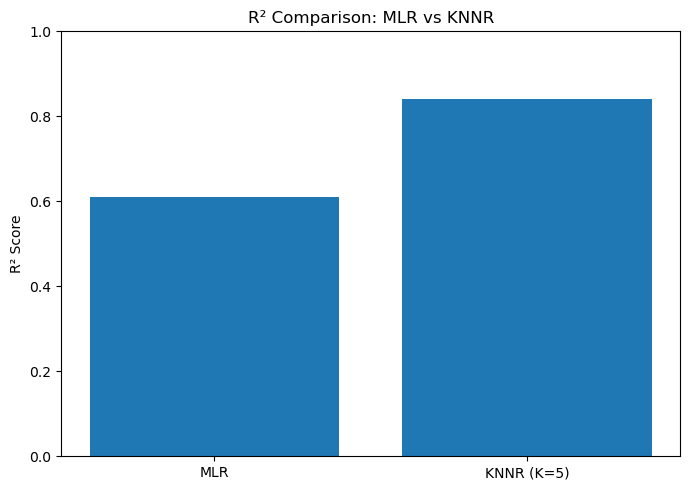

Plot saved: C:\Users\91630\Desktop\NIT\STIPEND\AIML\Assignment 2\Results\r2_comparison.png


In [13]:
# Plot and save the R² score comparison between MLR and KNNR

import matplotlib.pyplot as plt

models = ["MLR", "KNNR (K=5)"]
r2_values = [mlr_r2, 0.8414]

plt.figure(figsize=(7, 5))
plt.bar(models, r2_values)

plt.ylabel("R² Score")
plt.title("R² Comparison: MLR vs KNNR")
plt.ylim(0, 1)

plt.tight_layout()

plot_path = os.path.join(results_folder, "r2_comparison.png")
plt.savefig(plot_path, dpi=300)
plt.show()

print("Plot saved:", plot_path)

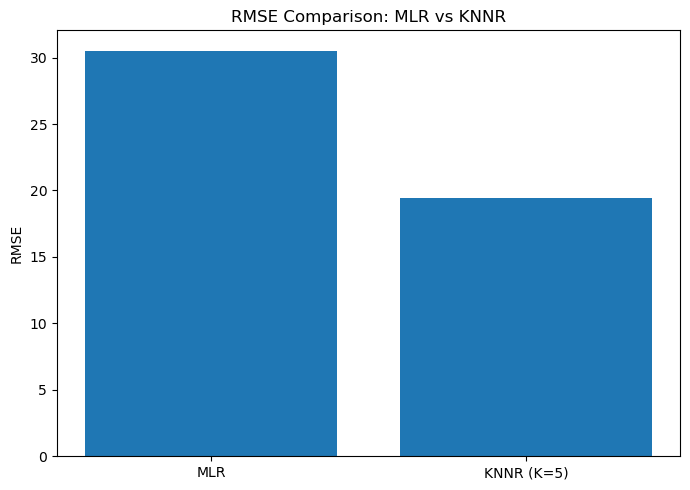

Plot saved: C:\Users\91630\Desktop\NIT\STIPEND\AIML\Assignment 2\Results\rmse_comparison.png


In [14]:
# Plot and save the RMSE comparison between MLR and KNNR

rmse_values = [mlr_rmse, 19.4689]

plt.figure(figsize=(7, 5))
plt.bar(models, rmse_values)

plt.ylabel("RMSE")
plt.title("RMSE Comparison: MLR vs KNNR")
plt.tight_layout()

plot_path = os.path.join(results_folder, "rmse_comparison.png")
plt.savefig(plot_path, dpi=300)
plt.show()

print("Plot saved:", plot_path)

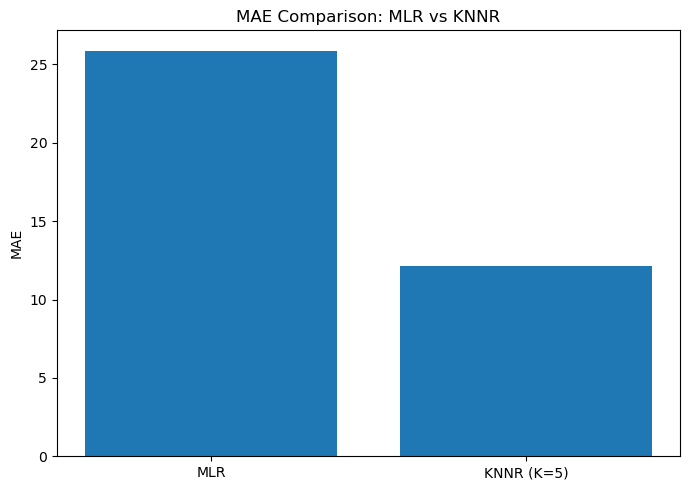

Plot saved: C:\Users\91630\Desktop\NIT\STIPEND\AIML\Assignment 2\Results\mae_comparison.png


In [15]:
# Plot and save the MAE comparison between MLR and KNNR

mae_values = [mlr_mae, 12.1591]

plt.figure(figsize=(7, 5))
plt.bar(models, mae_values)

plt.ylabel("MAE")
plt.title("MAE Comparison: MLR vs KNNR")
plt.tight_layout()

plot_path = os.path.join(results_folder, "mae_comparison.png")
plt.savefig(plot_path, dpi=300)
plt.show()

print("Plot saved:", plot_path)

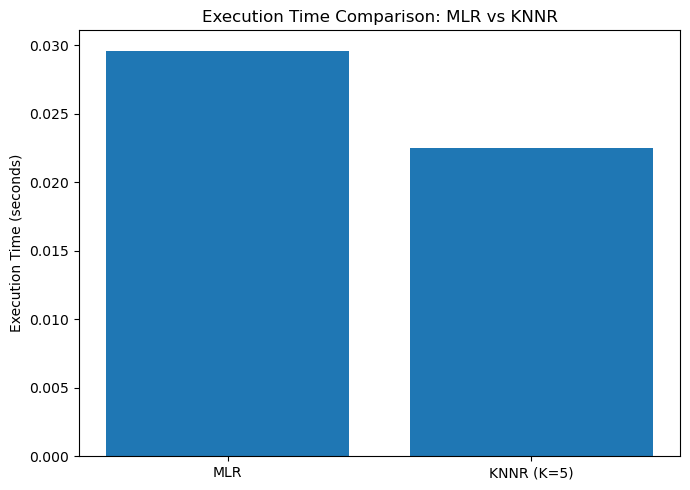

Plot saved: C:\Users\91630\Desktop\NIT\STIPEND\AIML\Assignment 2\Results\execution_time_comparison.png


In [16]:
# Plot and save the execution time comparison between MLR and KNNR

execution_times = [0.0296, 0.0225]

plt.figure(figsize=(7, 5))
plt.bar(models, execution_times)

plt.ylabel("Execution Time (seconds)")
plt.title("Execution Time Comparison: MLR vs KNNR")

plt.tight_layout()

plot_path = os.path.join(results_folder, "execution_time_comparison.png")
plt.savefig(plot_path, dpi=300)
plt.show()

print("Plot saved:", plot_path)

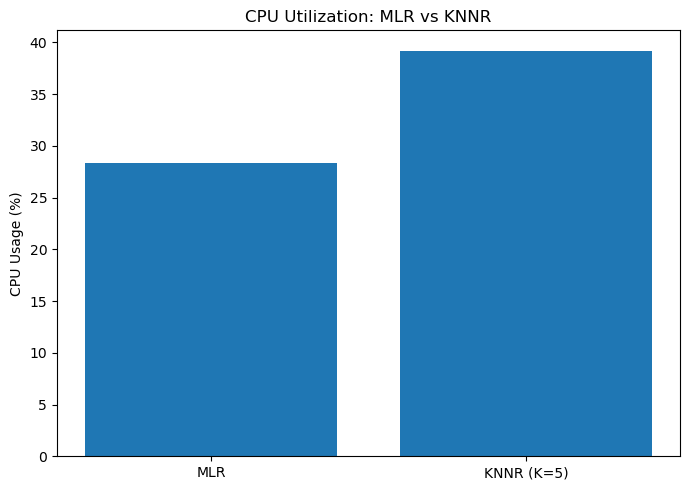

Plot saved: C:\Users\91630\Desktop\NIT\STIPEND\AIML\Assignment 2\Results\cpu_comparison.png


In [17]:
# Plot and save the observed CPU utilization comparison

cpu_values = [28.3, 39.2]

plt.figure(figsize=(7, 5))
plt.bar(models, cpu_values)

plt.ylabel("CPU Usage (%)")
plt.title("CPU Utilization: MLR vs KNNR")

plt.tight_layout()

plot_path = os.path.join(results_folder, "cpu_comparison.png")
plt.savefig(plot_path, dpi=300)
plt.show()

print("Plot saved:", plot_path)

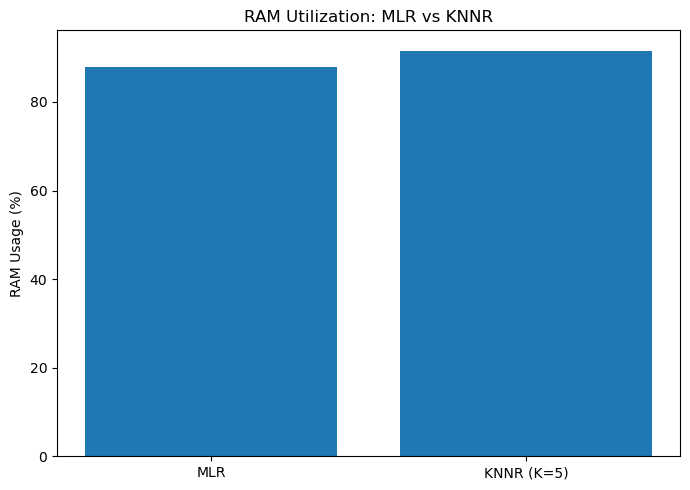

Plot saved: C:\Users\91630\Desktop\NIT\STIPEND\AIML\Assignment 2\Results\ram_comparison.png


In [18]:
# Plot and save the observed RAM utilization comparison

ram_values = [87.9, 91.6]

plt.figure(figsize=(7, 5))
plt.bar(models, ram_values)

plt.ylabel("RAM Usage (%)")
plt.title("RAM Utilization: MLR vs KNNR")

plt.tight_layout()

plot_path = os.path.join(results_folder, "ram_comparison.png")
plt.savefig(plot_path, dpi=300)
plt.show()

print("Plot saved:", plot_path)

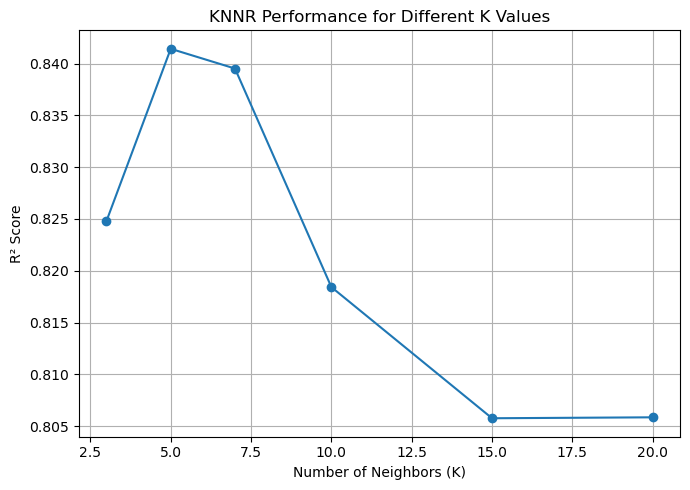

Plot saved: C:\Users\91630\Desktop\NIT\STIPEND\AIML\Assignment 2\Results\knnr_k_vs_r2.png


In [19]:
# Plot R² scores for different K values to identify the best KNN configuration

plt.figure(figsize=(7, 5))

plt.plot(
    knn_results_df["K"],
    knn_results_df["R2"],
    marker="o"
)

plt.xlabel("Number of Neighbors (K)")
plt.ylabel("R² Score")
plt.title("KNNR Performance for Different K Values")

plt.grid(True)
plt.tight_layout()

plot_path = os.path.join(results_folder, "knnr_k_vs_r2.png")
plt.savefig(plot_path, dpi=300)
plt.show()

print("Plot saved:", plot_path)

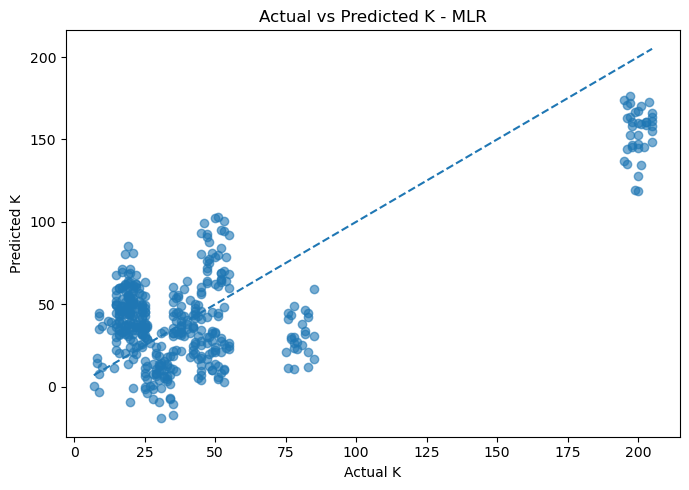

MLR plot saved: C:\Users\91630\Desktop\NIT\STIPEND\AIML\Assignment 2\Results\actual_vs_predicted_mlr.png


In [20]:
# Compare actual and predicted potassium values for the MLR model

y_pred_mlr_final = mlr.predict(X_test_scaled)

knn5 = KNeighborsRegressor(n_neighbors=5)
knn5.fit(X_train_scaled, y_train)
y_pred_knn_final = knn5.predict(X_test_scaled)

# Create plots
plt.figure(figsize=(7, 5))

plt.scatter(y_test, y_pred_mlr_final, alpha=0.6)

plt.xlabel("Actual K")
plt.ylabel("Predicted K")
plt.title("Actual vs Predicted K - MLR")

# Reference line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.tight_layout()

plot_path = os.path.join(results_folder, "actual_vs_predicted_mlr.png")
plt.savefig(plot_path, dpi=300)
plt.show()

print("MLR plot saved:", plot_path)

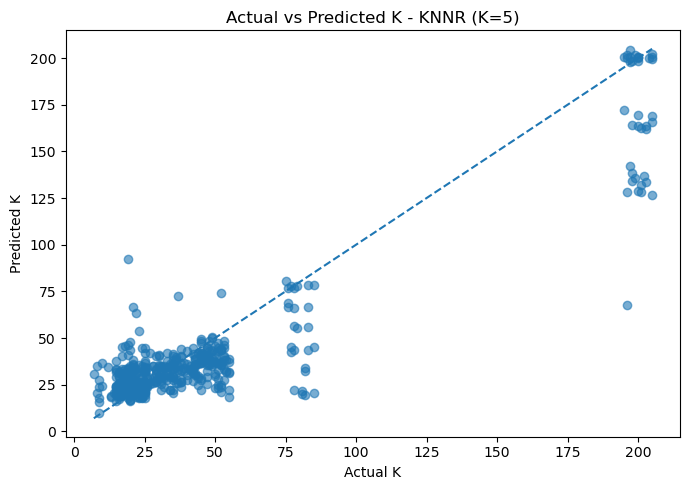

KNNR plot saved: C:\Users\91630\Desktop\NIT\STIPEND\AIML\Assignment 2\Results\actual_vs_predicted_knnr.png


In [21]:
# Compare actual and predicted potassium values for the KNNR model with K=5

plt.figure(figsize=(7, 5))

plt.scatter(y_test, y_pred_knn_final, alpha=0.6)

plt.xlabel("Actual K")
plt.ylabel("Predicted K")
plt.title("Actual vs Predicted K - KNNR (K=5)")

# Reference line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.tight_layout()

plot_path = os.path.join(results_folder, "actual_vs_predicted_knnr.png")
plt.savefig(plot_path, dpi=300)
plt.show()

print("KNNR plot saved:", plot_path)

In [22]:
final_results = pd.DataFrame({
    "Model": ["MLR", "KNNR (K=5)"],
    "R2": [mlr_r2, 0.8414],
    "RMSE": [mlr_rmse, 19.4689],
    "MAE": [mlr_mae, 12.1591],
    "Execution_Time_s": [0.0296, 0.0225],
    "CPU_After_%": [28.3, 39.2],
    "RAM_After_%": [87.9, 91.6]
})

print(final_results.round(4))

        Model      R2     RMSE      MAE  Execution_Time_s  CPU_After_%  \
0         MLR  0.6102  30.5232  25.8786            0.0296         28.3   
1  KNNR (K=5)  0.8414  19.4689  12.1591            0.0225         39.2   

   RAM_After_%  
0         87.9  
1         91.6  


In [23]:
# Create a final table summarizing model performance and resource utilization

final_results = pd.DataFrame({
    "Model": ["MLR", "KNNR (K=5)"],
    "R2": [mlr_r2, 0.8414],
    "RMSE": [mlr_rmse, 19.4689],
    "MAE": [mlr_mae, 12.1591],
    "Execution_Time_s": [0.0296, 0.0225],
    "CPU_After_%": [28.3, 39.2],
    "RAM_After_%": [87.9, 91.6]
})

print(final_results.round(4))

        Model      R2     RMSE      MAE  Execution_Time_s  CPU_After_%  \
0         MLR  0.6102  30.5232  25.8786            0.0296         28.3   
1  KNNR (K=5)  0.8414  19.4689  12.1591            0.0225         39.2   

   RAM_After_%  
0         87.9  
1         91.6  


In [24]:
# Create a final table summarizing model performance and resource utilization

final_results.to_csv(
    os.path.join(results_folder, "final_results.csv"),
    index=False
)

print("Final results saved:")
print(os.path.join(results_folder, "final_results.csv"))


Final results saved:
C:\Users\91630\Desktop\NIT\STIPEND\AIML\Assignment 2\Results\final_results.csv
